In [1]:
# IMPORTAR LIBRERÍAS

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)



I0000 00:00:1774716194.445165    6646 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774716195.562554    6646 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774716199.633271    6646 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0


In [2]:
# PARÁMETROS DEL MODELO

IMG_SIZE = 128      # Tamaño estándar para EfficientNetB0
BATCH_SIZE = 32     # Cantidad de imágenes por paso
EPOCHS = 5          # Número de veces que verá el dataset completo

NUM_CLASSES = 10    # Tienes 10 clases

In [3]:
# PREPROCESAMIENTO DE IMÁGENES

base_dir  = "../data"
train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

# Generador de entrenamiento CON data augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,          # Voltear horizontalmente
    vertical_flip=True,            # Voltear verticalmente
    rotation_range=30,             # Rotar hasta 30 grados
    brightness_range=[0.8, 1.2],   # Variar brillo
    zoom_range=0.1                 # Zoom leve
)

# Generador para validación y test SIN augmentation, solo normalización, para evaluar con imágenes reales
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Dataset de entrenamiento
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Dataset de validación
val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Dataset de test
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 5946 images belonging to 10 classes.
Found 1273 images belonging to 10 classes.
Found 1273 images belonging to 10 classes.


In [4]:
# CARGAR EFFICIENTNET-B0

base_model = EfficientNetB0(
    weights='imagenet',                 # Usa pesos ya entrenados
    include_top=False,                  # Quitamos la capa final original
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False            # Congelamos la red base

E0000 00:00:1774716203.601809    6646 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1774716203.602095    8230 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
E0000 00:00:1774716203.616159    6646 cuda_executor.cc:1827] Nvml call failed with 3(Not Supported). Assuming PCIe gen 3 x16 bandwidth.
W0000 00:00:1774716203.616714    6646 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
# CREAR CAPA FINAL PERSONALIZADA

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

In [6]:
# COMPILAR MODELO

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,829 (16.08 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [7]:
# ENTRENAMIENTO

# ENTRENAMIENTO CON EARLY STOPPING

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',     # Observa la pérdida en validación
    patience=5,             # Para si no mejora en 5 épocas seguidas
    restore_best_weights=True  # Restaura los pesos de la mejor época
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,              # Sube las épocas, el Early Stopping las controla
    callbacks=[early_stopping]
)

Epoch 1/50


I0000 00:00:1774716206.192507    6646 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


186/186 ━━━━━━━━━━━━━━━━━━━━ 152s 762ms/step - accuracy: 0.6519 - loss: 1.0268 - val_accuracy: 0.8264 - val_loss: 0.5341
Epoch 2/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 159s 852ms/step - accuracy: 0.8083 - loss: 0.5799 - val_accuracy: 0.8460 - val_loss: 0.4567
Epoch 3/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 158s 849ms/step - accuracy: 0.8360 - loss: 0.4905 - val_accuracy: 0.8775 - val_loss: 0.3850
Epoch 4/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 138s 742ms/step - accuracy: 0.8496 - loss: 0.4449 - val_accuracy: 0.8782 - val_loss: 0.3812
Epoch 5/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 144s 754ms/step - accuracy: 0.8602 - loss: 0.4025 - val_accuracy: 0.8963 - val_loss: 0.3402
Epoch 6/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 141s 755ms/step - accuracy: 0.8722 - loss: 0.3740 - val_accuracy: 0.8885 - val_loss: 0.3449
Epoch 7/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 140s 750ms/step - accuracy: 0.8725 - loss: 0.3582 - val_accuracy: 0.8995 - val_loss: 0.3070
Epoch 8/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 142s 753ms/step - accuracy: 0.8873 - loss: 0.34

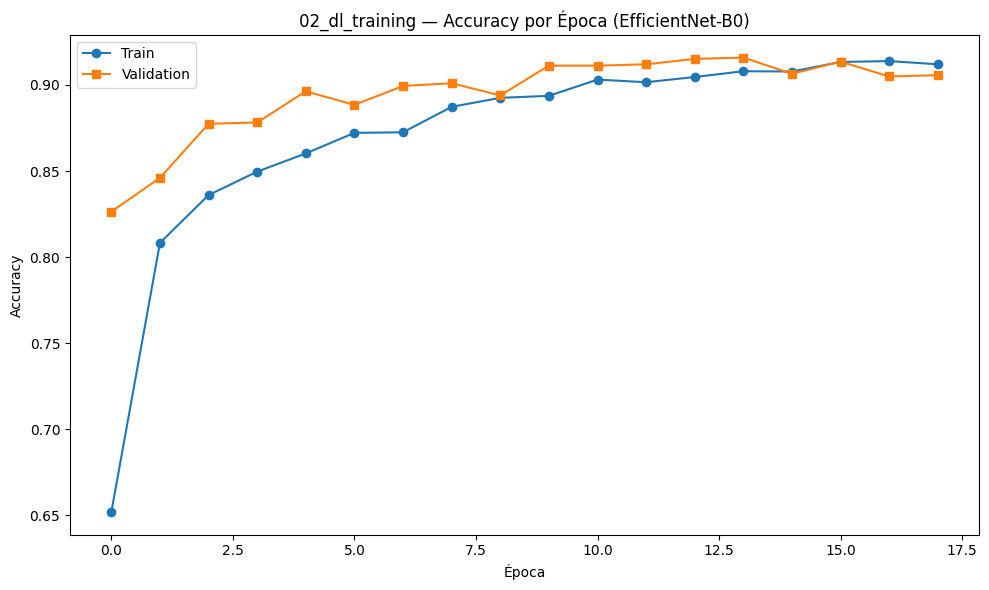

Gráfica guardada: ../outputs/graphics/02_dl_training_accuracy.png


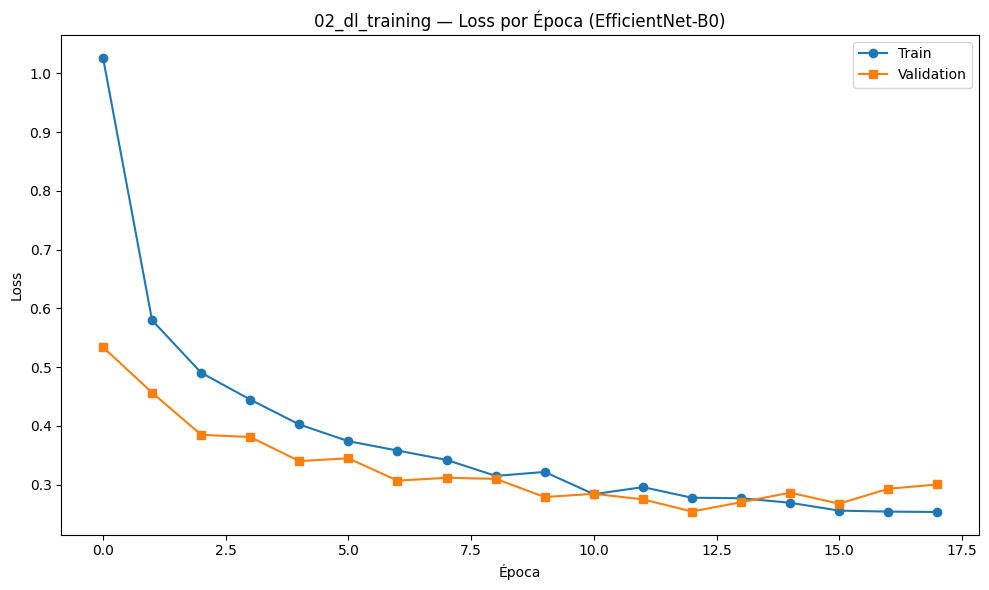

Gráfica guardada: ../outputs/graphics/02_dl_training_loss.png


In [8]:
# GRÁFICAS DE ENTRENAMIENTO

GRAPHICS_DIR = '../outputs/graphics'

# -- Accuracy --
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], marker='o', label='Train')
plt.plot(history.history['val_accuracy'], marker='s', label='Validation')
plt.title('02_dl_training — Accuracy por Época (EfficientNet-B0)')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig(f'{GRAPHICS_DIR}/02_dl_training_accuracy.png', dpi=150)
plt.show()
print(f'Gráfica guardada: {GRAPHICS_DIR}/02_dl_training_accuracy.png')

# -- Loss --
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], marker='o', label='Train')
plt.plot(history.history['val_loss'], marker='s', label='Validation')
plt.title('02_dl_training — Loss por Época (EfficientNet-B0)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig(f'{GRAPHICS_DIR}/02_dl_training_loss.png', dpi=150)
plt.show()
print(f'Gráfica guardada: {GRAPHICS_DIR}/02_dl_training_loss.png')


In [9]:
# MÉTRICAS

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
import seaborn as sns
import numpy as np

test_generator.reset()

predicciones = model.predict(
    test_generator,
    steps=test_generator.samples // BATCH_SIZE + 1
)

y_pred = np.argmax(predicciones, axis=1)
y_true = test_generator.classes

40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 652ms/step


[[ 75   0   0   0   0   0   0   0   0   0]
 [  0 132   0   1   1   9   3   3   1   0]
 [  0   0 101   0   0   1   2   0   0   1]
 [  0   3   0 135   0  10   2   0   0   0]
 [  0   0   0   0 128   1   7  14   0   0]
 [  0   1   0   4   0 137   5   0   0   3]
 [  0   0   0   1   3  10 132   4   0   0]
 [  0   0   0   0   4   0   2 144   0   0]
 [  0   1   0   1   0   3   0   0  38   0]
 [  0   0   0   0   0   5   1   0   0 144]]


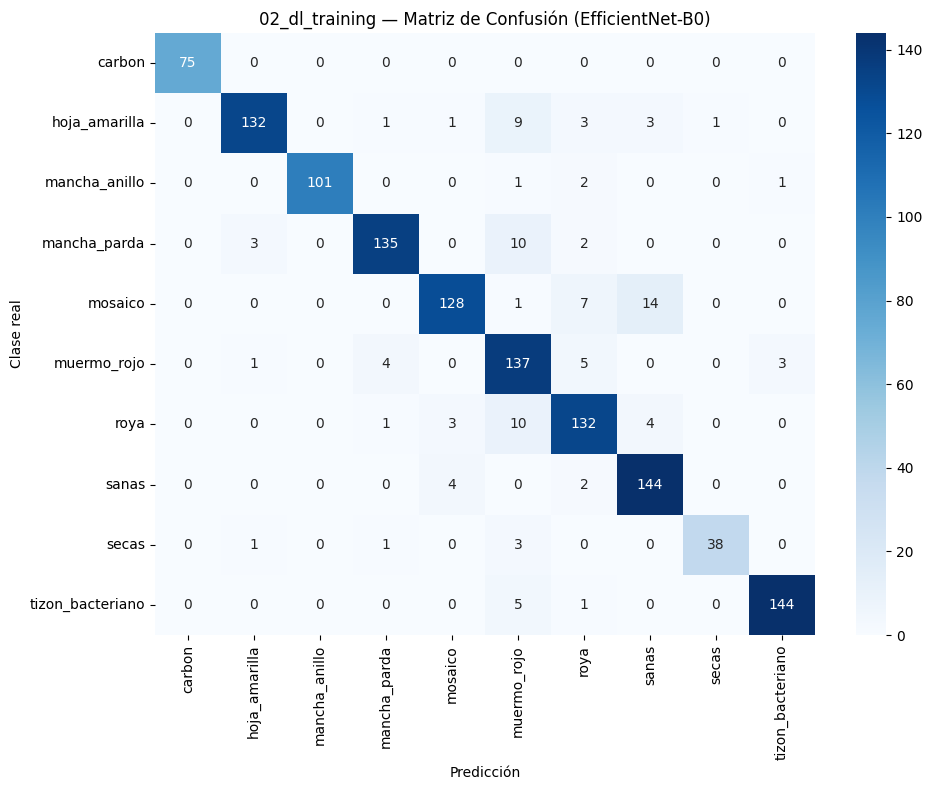

Gráfica guardada: ../outputs/graphics/02_dl_training_confusion_matrix.png


In [10]:
# MATRIZ DE CONFUSIÓN

cm = confusion_matrix(y_true, y_pred)
print(cm)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=test_generator.class_indices.keys(),
    yticklabels=test_generator.class_indices.keys()
)

plt.xlabel('Predicción')
plt.ylabel('Clase real')
plt.title('02_dl_training — Matriz de Confusión (EfficientNet-B0)')
plt.tight_layout()
plt.savefig(f'{GRAPHICS_DIR}/02_dl_training_confusion_matrix.png', dpi=150)
plt.show()
print(f'Gráfica guardada: {GRAPHICS_DIR}/02_dl_training_confusion_matrix.png')


In [11]:
# F1 SCORE

f1 = f1_score(y_true, y_pred, average='weighted')
print("F1 Score:", f1)

F1 Score: 0.916892662754926


In [12]:
# REPORTE DE CLASIFICACIÓN

print(classification_report(
    y_true,
    y_pred,
    target_names=test_generator.class_indices.keys()
))

                  precision    recall  f1-score   support

          carbon       1.00      1.00      1.00        75
   hoja_amarilla       0.96      0.88      0.92       150
   mancha_anillo       1.00      0.96      0.98       105
    mancha_parda       0.95      0.90      0.92       150
         mosaico       0.94      0.85      0.90       150
     muermo_rojo       0.78      0.91      0.84       150
            roya       0.86      0.88      0.87       150
           sanas       0.87      0.96      0.91       150
           secas       0.97      0.88      0.93        43
tizon_bacteriano       0.97      0.96      0.97       150

        accuracy                           0.92      1273
       macro avg       0.93      0.92      0.92      1273
    weighted avg       0.92      0.92      0.92      1273



In [13]:
# GUARDAR EL MODELO

model.save('../models/dl_best_model.keras')